# Homework 3
## PART A:

### 1. Describe the importance of training and test data. Why do we separate data into these subsets?

Training data is used to fit the model, while test data is used to evaluate how well the model performs on new, unseen observations. We separate them to measure generalization accurately and to reduce the risk of overfitting, where a model performs well on the training data but poorly on other data.

### 2. What is k-fold cross validation and what do we use it for?

K-fold cross-validation is a method where the data is divided into K roughly equal parts, and the model is trained K times, each time using K−1 folds for training and the remaining fold for validation. We use it to get a more reliable estimate of out-of-sample model performance and to help choose between models or tuning parameters without relying on just one train-test split.

### 3. How is k-fold cross validation different from stratified k-fold cross validation?

K-fold cross-validation splits the data into K folds without necessarily preserving the proportion of outcome classes in each fold. Stratified k-fold cross-validation does preserve those class proportions across folds, so it is especially useful in classification problems when the classes are imbalanced.

### 4. Give examples of 4 different supervised learning models that we have learned thus far that are used to predict categorical dependent variables like whether an email is labeled “spam” or “not spam.” Each example should reflect a different type of model (e.g., ridge and lasso are the same type of model, just with a different regularization setting).

Four examples of supervised learning models are:
1. KNN, which is an instance-based model,
2. logistic regression, which is a parametric linear model,
3. support vector machines, which is a kernel / margin-based model, and
4. decision trees, which is a tree-based model.

These are all supervised learning models that can be used to predict categorical dependent variables like whether an email is labeled "spam" or "not spam".

### 5. Give examples of 3 different supervised learning models that we have learned thus far that are used to predict continuous dependent variables like test scores. Each example should reflect a different type of model (e.g., ridge and lasso are the same type of model, just with a different regularization setting).

Three examples of supervised learning models are:

1. KNN, which is an instance-based model,
2. ridge regression, which is a parametric linear model, and
3. decision trees, which is a tree-based model.

These are all supervised learning models that can be used to predict continuous dependent variables like test scores.

# Part B:

#### For the following questions, use the spam dataset and variable descriptions located in the Homework 3 Data folder in this course’s Files on Courseworks.


### 1. Import the spam dataset and print the first six rows.

In [ ]:
# Import Python Libraries
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

# Upload the dataset from my computer
uploaded = files.upload()

# Load the spam dataset
spam = pd.read_csv("spam_dataset.csv")

# Description: This dataset contains 4,601 emails and 58 variables and is used
# to predict whether an email is spam or not spam. Most predictors measure the
# frequency of specific words or characters, while the final variable, spam,
# indicates whether the email was classified as spam (1) or not spam (0).

# Print the first six rows
spam.head(6)

Saving spam_dataset.csv to spam_dataset.csv


,word_freq_make:,word_freq_address:,word_freq_all:,word_freq_3d:,word_freq_our:,word_freq_over:,word_freq_remove:,word_freq_internet:,word_freq_order:,word_freq_mail:,...,char_freq_;:,char_freq_(:,char_freq_[:,char_freq_!:,char_freq_$:,char_freq_#:,capital_run_length_average:,capital_run_length_longest:,capital_run_length_total:,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1


### 2. Read through the documentation of the original dataset here: http://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names The dependent variable is "spam" where one indicates that an email is spam and zero otherwise. Which three variables in the dataset do you think will be important predictors in a model of spam? Why?

Three variables that are likely to be important predictors are word_freq_money:, char_freq_!:, and capital_run_length_total:. These variables capture common characteristics of spam emails: promotional language (e.g., “money”), excessive use of punctuation to attract attention, and unusually high levels of capitalization. According to the dataset description, these variables measure the frequency of specific words or characters and patterns of capital letter usage within each email. Because spam messages are often designed to advertise, persuade, or draw attention, they tend to have higher values for these features, making them useful predictors for distinguishing spam from non-spam emails.



### 3. Visualize the univariate distribution of each of the variables you selected in the previous question.  


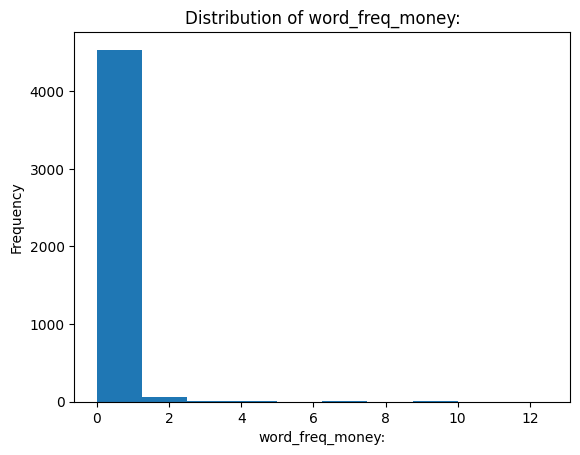

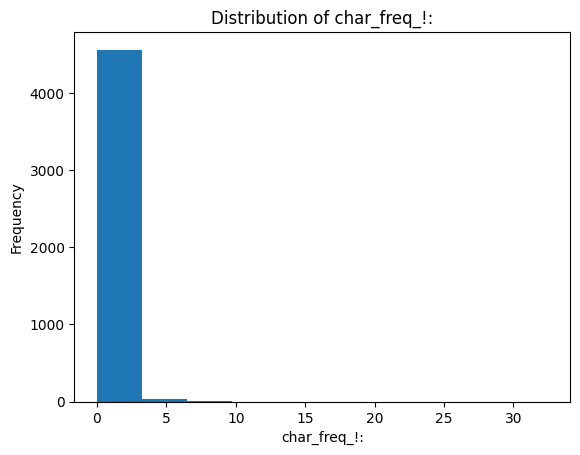

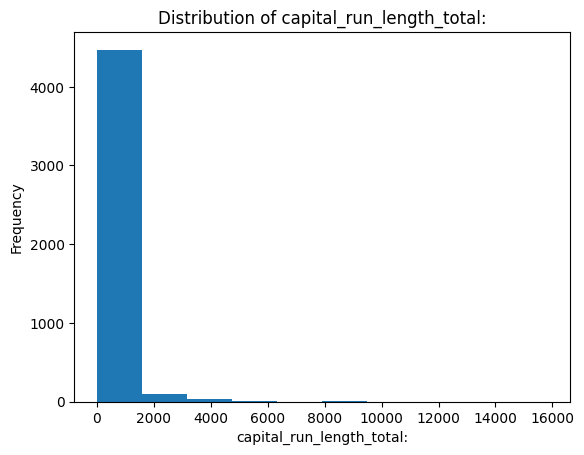

In [ ]:
# Variables selected
vars_to_plot = ["word_freq_money:", "char_freq_!:", "capital_run_length_total:"]

# Plot histograms
for var in vars_to_plot:
    plt.figure()
    plt.hist(spam[var])
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

### 4. Choose one model from Part A Question 4. Split the data into training and test subsets. Build a model with the three variables in the dataset that you think will be good predictors of "spam". Run the model and evaluate prediction error using 10-fold cross-validation. Justify why you chose any particular parameters for your model (e.g., if you used KNN how did you decide the specific value for k? Hint: it should involve comparing performance).

In [ ]:
# Import Libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define predictors and outcome
X = spam.loc[:, ["word_freq_money:", "char_freq_!:", "capital_run_length_total:"]]
y = spam['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

# KNN Classification with StandardScaler
pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

# create a dictionary data object with keys equal to parameter name 'n_neighbors'
# for knn model and values equal to range of k values to create models for
param_grid = {'knn__n_neighbors': np.arange(1, 21, 2)} #np.arange creates sequence of numbers for each k value
grid = GridSearchCV(pipe, param_grid=param_grid, cv=10)

# use model methods to fit score and predict model:
grid.fit(X_train, y_train)

# extract best score and parameter by calling objects "best_score_" and "best_params_"
print("Best score with Standard Scaler")
print("Best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("Best parameters: {}".format(grid.best_params_))
print("Test set score: {:.3f}".format(grid.score(X_test, y_test)))


Best score with Standard Scaler
Best mean cross-validation score: 0.849
Best parameters: {'knn__n_neighbors': np.int64(15)}
Test set score: 0.851


I selected the value of k using grid search with 10-fold cross-validation, comparing performance across odd values from 1 to 19. The model with k = 15 achieved the highest cross-validation accuracy of 0.849. The final model achieved a test accuracy of 0.851, corresponding to a prediction error of 0.149. The similar performance between cross-validation and test results suggests that the model generalizes well and does not overfit.

### 5. Repeat the previous question but with a different model from Question 4.

In [ ]:
# Import Libraries
from sklearn.linear_model import LogisticRegression

# Logistic Regression with StandardScaler
pipe_log = Pipeline([("scaler", StandardScaler()), ("log", LogisticRegression(penalty="l2", max_iter=10000))])

# Create a grid of C values to compare
# Smaller C means stronger regularization; larger C means weaker regularization
param_grid = {"log__C": [0.01, 0.1, 1, 10, 100]}

# Use 10-fold cross-validation to choose the best value of C
grid = GridSearchCV(pipe_log, param_grid=param_grid, cv=10)

# Fit the model on the training data
grid.fit(X_train, y_train)

# Print results
print("Logistic Regression with StandardScaler")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score: {:.3f}".format(grid.best_score_))
print("Test set score: {:.3f}".format(grid.score(X_test, y_test)))
print("Test set prediction error: {:.3f}".format(1 - grid.score(X_test, y_test)))

# Print coefficients and intercept from the best model
best_log = grid.best_estimator_.named_steps["log"]
print("log.coef_: " + str(best_log.coef_))
print("log.intercept_: {}".format(best_log.intercept_))

Logistic Regression with StandardScaler
Best parameters: {'log__C': 10}
Best cross-validation score: 0.783
Test set score: 0.773
Test set prediction error: 0.227
log.coef_: [[1.12002109 1.66652975 0.74660499]]
log.intercept_: [-0.25474278]


I used logistic regression with standardized variables and selected the regularization parameter C using 10-fold cross-validation over a range of values from 0.01 to 100. The value of C that achieved the highest cross-validation accuracy was C = 10, with a score of 0.783. The final model achieved a test accuracy of 0.773, corresponding to a prediction error of 0.227. The similar performance between cross-validation and test results suggests that the model generalizes reasonably well to new data.


### 6. Repeat the previous question but with a different model from Question 4.

In [ ]:
# Import Libraries
from sklearn.svm import LinearSVC

# Support Vector Machines with StandardScaler
pipe = Pipeline([("scaler", StandardScaler()), ("clf", LinearSVC(max_iter=10000))])

# Hyperparameter grid
param_grid = {'clf__C': [1, 100, 10000]}

# Grid search with 10-fold CV
grid = GridSearchCV(pipe, param_grid, cv=10)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score: {:.3f}".format(grid.best_score_))
print("Training set score: {:.3f}".format(grid.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid.score(X_test, y_test)))

Best parameters: {'clf__C': 1}
Best cross-validation score: 0.723
Training set score: 0.719
Test set score: 0.712


I selected the value of C using grid search with 10-fold cross-validation, comparing performance across values of 1, 100, and 10000. This approach provides an estimate of generalization performance and balances model complexity against fit to the training data. The model with C = 1 achieved the highest cross-validation accuracy of 0.723. It also achieved a training accuracy of 0.719 and a test accuracy of 0.712, corresponding to a prediction error of 0.288. Because the training, cross-validation, and test results are all fairly similar, the model appears to generalize reasonably well without substantial overfitting.

### 7. Repeat the previous question but with a different model from Question 4.

In [ ]:
# Import Libraries
from sklearn.tree import DecisionTreeClassifier

# Decision Trees model
# Define parameter grid (tree depth)
param_grid = {'max_depth': [2, 4, 6, 8, 10]}

# Grid search with 10-fold cross-validation
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=10)
grid.fit(X_train, y_train)

# Print results
print("Decision Tree")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score: {:.3f}".format(grid.best_score_))
print("Training set score: {:.3f}".format(grid.score(X_train, y_train)))
print("Test set score: {:.3f}".format(grid.score(X_test, y_test)))
print("Test set prediction error: {:.3f}".format(1 - grid.score(X_test, y_test)))

Decision Tree
Best parameters: {'max_depth': 6}
Best cross-validation score: 0.851
Training set score: 0.874
Test set score: 0.839
Test set prediction error: 0.161


I used a decision tree model and selected the maximum depth parameter using grid search with 10-fold cross-validation. I compared performance across different values of maximum depth and selected the value that achieved the highest cross-validation accuracy. The best model had max_depth = 6, with a cross-validation accuracy of 0.851. The final model achieved a training accuracy of 0.874 and a test accuracy of 0.839, corresponding to a prediction error of 0.161. Because the training and test results are fairly close, the model appears to generalize reasonably well, although the slightly higher training accuracy suggests some mild overfitting.

### 8. Now rerun your best-performing model with 3 additional variables that you think will help the prediction accuracy. Did this cause the performance to improve over your previous models?

In [ ]:
# Add 3 additional variables: word_freq_free:, word_freq_credit:, capital_run_length_longest:
X = spam.loc[:, ["word_freq_money:", "char_freq_!:", "capital_run_length_total:", "word_freq_free:", "word_freq_credit:", "capital_run_length_longest:"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

### KNN Classification with StandardScaler
pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

# create a dictionary data object with keys equal to parameter name 'n_neighbors'
# for knn model and values equal to range of k values to create models for
param_grid = {'knn__n_neighbors': np.arange(1, 21, 2)} #np.arange creates sequence of numbers for each k value
grid = GridSearchCV(pipe, param_grid=param_grid, cv=10)

# use model methods to fit score and predict model:
grid.fit(X_train, y_train)

# extract best score and parameter by calling objects "best_score_" and "best_params_"
print("\nBest score with Standard Scaler and 6 variables")
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))
print("test-set score: {:.3f}".format(grid.score(X_test, y_test)))



Best score with Standard Scaler and 6 variables
best mean cross-validation score: 0.869
best parameters: {'knn__n_neighbors': np.int64(5)}
test-set score: 0.874


I selected KNN as my best-performing model based on its highest test accuracy among the models considered. I added three additional variables: word_freq_free:, word_freq_credit:, and capital_run_length_longest:, as they capture additional patterns associated with spam emails, including promotional language and capitalization. With these additional variables, the model's cross-validation accuracy increased from 0.849 to 0.869, and the test accuracy increased from 0.851 to 0.874. The optimal value of k changed from 15 to 5, indicating that with more informative features, the model benefits from a more localized neighborhood. Overall, these results indicate that the additional variables improved the model's predictive performance and generalization.

### 9. What is a variable that isn't available in this dataset but you think could increase your final model's predictive power if you had it? Why do you think it would improve your model?



One variable that is not available in this dataset but could improve my final model's predictive power is the number of hyperlinks in an email. I think this would improve the model because spam emails often contain multiple links that direct recipients to external websites, promotional pages, or fraudulent login pages. Unlike the variables already in the dataset, which mainly capture word frequencies, character frequencies, and capitalization patterns, the number of hyperlinks would provide additional structural information about the email. Because this feature captures a different aspect of spam behavior, it could complement the existing predictors and help the model distinguish spam from legitimate emails more accurately.